# B2 Explainability — SHAP and Domain Attribution

Explains the **final XGBoost model only**, on held-out test data, using the
exact locked-test setup from B2. This notebook computes **predictive
attribution only** — SHAP explains what the model learned, not a causal
mechanism, and nothing here is interpreted as a causal effect.

**Not run here.** Written but not executed, and no commands were run, no
model was fit, and no data was touched while authoring this notebook, per
instruction. Run it locally in VS Code.

**Model-artifact note, stated plainly:** the B2 notebook
(`03_v2_predictive_model_and_calibration.ipynb`) saved performance tables,
calibration metrics, and prediction CSVs, but did not persist a serialized
model object (e.g. via `joblib`). So this notebook first checks for a saved
pipeline at `outputs/models/b2_xgboost_pipeline.joblib`; if it isn't there,
it **deterministically refits** the identical XGBoost pipeline — same
predictor set, same respondent-grouped split (same `random_state`), same
reused v1 hyperparameters — and then validates that refit against B2's
already-saved performance numbers before trusting it for SHAP. If you'd
rather not refit, add one line to the end of the B2 notebook:
`joblib.dump(xgb_pipeline, Path("../../outputs/models/b2_xgboost_pipeline.joblib"))`
(creating the `outputs/models/` folder first) and this notebook will pick it
up automatically next run.

## 1. Imports and paths

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")
VARIABLE_DICT_PATH = Path("../../data/processed/variable_dictionary_v2.csv")
MODEL_ARTIFACT_PATH = Path("../../outputs/models/b2_xgboost_pipeline.joblib")
B2_PERFORMANCE_PATH = Path("../../outputs/tables/b2_model_performance.csv")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 5000  # matches v1's precedent; capped automatically if the test set is smaller

## 2. Load `df_model_v2` (read-only) and re-assert dataset integrity

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. "
    f"Stop and investigate before proceeding."
)
print(f"Loaded shape: {df.shape} -- matches the frozen Step 2 value.")

Loaded shape: (201311, 53) -- matches the frozen Step 2 value.


## 3. Rebuild the approved predictor set, split, and pipeline (identical to B2)

Duplicated deliberately from the B2 notebook so this notebook is
self-contained and reproducible on its own, rather than silently depending
on B2 having been run first in the same kernel session.

In [3]:
numeric_features = [
    "maternal_age", "education_years", "wealth_index", "birth_order",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "bmi", "first_anc_timing", "anc_visits",
]
categorical_features = ["facility_type", "residence", "religion", "social_group", "twin_order"]
binary_features = [
    "health_insurance", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "weight_measured_during_pregnancy", "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
]
feature_cols = numeric_features + categorical_features + binary_features
assert len(feature_cols) == 36

forbidden_columns = {
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023", "state", "district",
    "csection", "delivery_place_code",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}
assert forbidden_columns.isdisjoint(set(feature_cols)), "Forbidden column found in predictor set."

X = df[feature_cols].copy()
for col in categorical_features + binary_features:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)
assert len(X) == n_loaded, "Row count changed while building the predictor matrix."

y = df["csection"].astype(int)
groups = df["respondent_id"].copy()

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx].copy(), groups.iloc[test_idx].copy()

overlap_respondents = set(groups_train) & set(groups_test)
assert not overlap_respondents, f"Respondent leakage detected: {len(overlap_respondents)}"
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Respondent overlap: {len(overlap_respondents)} (confirmed zero)")

Train: (161048, 36) | Test: (40263, 36) | Respondent overlap: 0 (confirmed zero)


## 4. Load the saved model if available, otherwise refit deterministically

In [4]:
tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features + binary_features),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    colsample_bytree=0.7141915784487018,
    gamma=0.6084844859190754,
    learning_rate=0.048164145309070844,
    max_depth=6,
    min_child_weight=9,
    n_estimators=198,
    reg_alpha=0.012563152773938664,
    reg_lambda=0.6305535040199283,
    subsample=0.6663329821247654,
)  # reused from v1 05_hyperparameter_tuning.ipynb -- same as B2, cited there in full

if MODEL_ARTIFACT_PATH.exists():
    xgb_pipeline = joblib.load(MODEL_ARTIFACT_PATH)
    model_source = f"loaded from {MODEL_ARTIFACT_PATH}"
    print(f"Loaded saved model pipeline from {MODEL_ARTIFACT_PATH}")
else:
    xgb_pipeline = Pipeline([("pre", tree_preprocessor), ("clf", XGBClassifier(**xgb_params))])
    xgb_pipeline.fit(X_train, y_train)
    model_source = "refit in this notebook (no saved artifact found at MODEL_ARTIFACT_PATH)"
    print(f"No saved model found at {MODEL_ARTIFACT_PATH} -- refit deterministically instead.")

print("Model source:", model_source)

No saved model found at ..\..\outputs\models\b2_xgboost_pipeline.joblib -- refit deterministically instead.
Model source: refit in this notebook (no saved artifact found at MODEL_ARTIFACT_PATH)


## 5. Consistency check against B2's saved performance

If B2's performance CSV is available, confirms this notebook's model
(loaded or refit) reproduces those numbers within a small tolerance, before
trusting it for SHAP. If B2's CSV isn't present, this is skipped with a
clear warning rather than failing silently.

In [5]:
xgb_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
fresh_roc_auc = roc_auc_score(y_test, xgb_test_proba)
fresh_pr_auc = average_precision_score(y_test, xgb_test_proba)
fresh_brier = brier_score_loss(y_test, xgb_test_proba)

print(f"This notebook's model on the locked test set -- ROC-AUC: {fresh_roc_auc:.4f}, "
      f"PR-AUC: {fresh_pr_auc:.4f}, Brier: {fresh_brier:.4f}")

TOLERANCE = 0.005
if B2_PERFORMANCE_PATH.exists():
    b2_performance = pd.read_csv(B2_PERFORMANCE_PATH)
    b2_xgb_row = b2_performance[b2_performance["model"] == "XGBoost"]
    if len(b2_xgb_row) == 1:
        b2_roc_auc = float(b2_xgb_row["roc_auc"].iloc[0])
        b2_pr_auc = float(b2_xgb_row["pr_auc"].iloc[0])
        roc_diff = abs(fresh_roc_auc - b2_roc_auc)
        pr_diff = abs(fresh_pr_auc - b2_pr_auc)
        print(f"B2-recorded -- ROC-AUC: {b2_roc_auc:.4f} (diff {roc_diff:.4f}), "
              f"PR-AUC: {b2_pr_auc:.4f} (diff {pr_diff:.4f})")
        if roc_diff > TOLERANCE or pr_diff > TOLERANCE:
            print("WARNING: this notebook's model diverges from B2's recorded performance "
                  "by more than the tolerance -- investigate before trusting the SHAP results below.")
        else:
            print("Consistent with B2's recorded performance within tolerance.")
    else:
        print("WARNING: could not find a single 'XGBoost' row in b2_model_performance.csv -- skipping check.")
else:
    print(f"WARNING: {B2_PERFORMANCE_PATH} not found -- cannot cross-check against B2. Proceeding without it.")

This notebook's model on the locked test set -- ROC-AUC: 0.8037, PR-AUC: 0.5334, Brier: 0.1825
B2-recorded -- ROC-AUC: 0.8037 (diff 0.0000), PR-AUC: 0.5334 (diff 0.0000)
Consistent with B2's recorded performance within tolerance.


## 6. Draw a reproducible, representative SHAP sample — from locked test records only

Class-stratified sampling (same class balance as the full test set), fixed
seed, capped at the available test size. Explicitly asserted to be a subset
of the test index — never train.

In [6]:
sample_size = min(SHAP_SAMPLE_SIZE, len(X_test))

rng = np.random.RandomState(RANDOM_STATE)
sample_indices = []
for label in [0, 1]:
    label_index = y_test[y_test == label].index
    label_share = len(label_index) / len(y_test)
    n_for_label = max(1, round(sample_size * label_share))
    chosen = rng.choice(label_index, size=min(n_for_label, len(label_index)), replace=False)
    sample_indices.extend(chosen)

shap_sample_index = pd.Index(sample_indices)
X_shap_sample = X_test.loc[shap_sample_index]
y_shap_sample = y_test.loc[shap_sample_index]

# Explicit check: the SHAP sample must come only from locked test records.
assert set(shap_sample_index).issubset(set(X_test.index)), "SHAP sample includes non-test records."
assert set(shap_sample_index).isdisjoint(set(X_train.index)), "SHAP sample overlaps with training records."

print(f"SHAP sample size: {len(X_shap_sample)} (requested {SHAP_SAMPLE_SIZE}, capped at test size {len(X_test)})")
print(f"Sample class balance: {y_shap_sample.mean():.4f} (test set overall: {y_test.mean():.4f})")

SHAP sample size: 5000 (requested 5000, capped at test size 40263)
Sample class balance: 0.2222 (test set overall: 0.2223)


## 7. Transform the sample and build the transformed → original feature mapping

Verifies mapping completeness explicitly: every transformed output feature
maps to exactly one original predictor, every original predictor is
represented by at least one transformed feature, and nothing is left
unmapped or duplicated.

In [7]:
preprocessor = xgb_pipeline.named_steps["pre"]
classifier = xgb_pipeline.named_steps["clf"]

X_shap_transformed = preprocessor.transform(X_shap_sample)
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

transformed_feature_names = preprocessor.get_feature_names_out()
print(f"Transformed feature count: {len(transformed_feature_names)}")


def map_transformed_to_original(name, numeric_cols, cat_bin_cols):
    """Maps one ColumnTransformer output feature name back to its original column."""
    if name.startswith("num__"):
        remainder = name[len("num__"):]
        if remainder.startswith("missingindicator_"):
            original = remainder[len("missingindicator_"):]
        else:
            original = remainder
        assert original in numeric_cols, f"Unrecognized numeric-branch feature: {name}"
        return original
    if name.startswith("cat__"):
        remainder = name[len("cat__"):]
        # Longest-prefix match against known categorical/binary columns to avoid
        # ambiguity between similarly-named columns (e.g. anc_doctor vs anc_other_provider).
        candidates = [c for c in cat_bin_cols if remainder == c or remainder.startswith(c + "_")]
        assert len(candidates) >= 1, f"No original column matched for: {name}"
        original = max(candidates, key=len)
        return original
    raise AssertionError(f"Unrecognized feature-name branch: {name}")


cat_bin_cols = categorical_features + binary_features
transformed_to_original = {
    name: map_transformed_to_original(name, numeric_features, cat_bin_cols)
    for name in transformed_feature_names
}

# --- Completeness checks ---
mapped_originals = set(transformed_to_original.values())
expected_originals = set(feature_cols)
unmapped_originals = expected_originals - mapped_originals
assert not unmapped_originals, f"Original predictors with no transformed feature mapped to them: {unmapped_originals}"

extra_originals = mapped_originals - expected_originals
assert not extra_originals, f"Transformed features mapped to unexpected original columns: {extra_originals}"

assert len(transformed_to_original) == len(transformed_feature_names), \
    "Duplicate transformed feature names encountered -- mapping is not one-to-one on the transformed side."

print(f"All {len(transformed_feature_names)} transformed features mapped to exactly one of the {len(expected_originals)} original predictors.")
print("No unmapped or duplicated features.")

Transformed feature count: 99
All 99 transformed features mapped to exactly one of the 36 original predictors.
No unmapped or duplicated features.


## 8. Compute SHAP values (TreeExplainer) on the transformed sample

In [8]:
explainer = shap.TreeExplainer(classifier)
raw_explanation = explainer(X_shap_transformed)

shap_matrix = raw_explanation.values
# Some SHAP/XGBoost version combinations return a 3D array (n_samples, n_features, n_classes)
# for classifiers; select the positive class (C-section = 1) in that case.
if shap_matrix.ndim == 3:
    shap_matrix = shap_matrix[:, :, 1]

assert shap_matrix.shape == (len(X_shap_sample), len(transformed_feature_names)), (
    f"Unexpected SHAP matrix shape {shap_matrix.shape}, expected "
    f"({len(X_shap_sample)}, {len(transformed_feature_names)})"
)
print("SHAP matrix shape:", shap_matrix.shape)

SHAP matrix shape: (5000, 99)


## 9. Global original-feature importance (mean |SHAP|, aggregated across one-hot/indicator columns)

In [9]:
mean_abs_shap_transformed = np.abs(shap_matrix).mean(axis=0)

transformed_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "original_feature": [transformed_to_original[n] for n in transformed_feature_names],
    "mean_abs_shap": mean_abs_shap_transformed,
})

original_feature_importance = (
    transformed_importance
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
original_feature_importance["is_facility_type"] = original_feature_importance["original_feature"] == "facility_type"
original_feature_importance["share_pct"] = (
    original_feature_importance["mean_abs_shap"] / original_feature_importance["mean_abs_shap"].sum() * 100
)

original_feature_importance.to_csv(TABLES_DIR / "b2_shap_original_feature_importance.csv", index=False)
original_feature_importance.head(15)

,original_feature,mean_abs_shap,is_facility_type,share_pct
0,facility_type,0.681260,True,25.049007
1,total_children_ever_born,0.260662,False,9.584181
2,bmi,0.246951,False,9.080058
3,wealth_index,0.167896,False,6.173322
4,anc_doctor,0.143342,False,5.270484
5,age_at_first_birth,0.141405,False,5.199272
6,education_years,0.133077,False,4.893059
7,anc_visits,0.127433,False,4.685541
8,social_group,0.098136,False,3.608314
9,preceding_birth_interval,0.077484,False,2.848978


## 10. Domain-level attribution

Uses the frozen `variable_dictionary_v2.csv` domain field, with one explicit
override: `facility_type` is tagged `exposure` in the dictionary (correct
for the causal branch) but is analyzed here as its own predictor within the
**health-service/facility** domain, per instruction. Coverage of all 36
predictors across exactly the 3 approved domains is asserted, not assumed.

In [10]:
variable_dictionary = pd.read_csv(VARIABLE_DICT_PATH)
raw_domain_map = dict(zip(variable_dictionary["column"], variable_dictionary["domain"]))


def map_to_approved_domain(column, raw_domain):
    if column == "facility_type":
        return "health_service_facility"  # explicit override -- see markdown above
    if raw_domain == "maternal_clinical":
        return "maternal_reproductive_clinical_proxy"
    if isinstance(raw_domain, str) and raw_domain.startswith("anc_service"):
        return "health_service_facility"
    if raw_domain == "socioeconomic_geographic":
        return "socioeconomic_geographic"
    return None  # anything else (survey_design, outcome, exposure-raw) should not be a model predictor


approved_domains = {"maternal_reproductive_clinical_proxy", "health_service_facility", "socioeconomic_geographic"}

original_feature_importance["domain"] = original_feature_importance["original_feature"].apply(
    lambda col: map_to_approved_domain(col, raw_domain_map.get(col))
)

unmapped = original_feature_importance[~original_feature_importance["domain"].isin(approved_domains)]
assert unmapped.empty, f"Predictors not mapped to one of the 3 approved domains: {unmapped['original_feature'].tolist()}"

domain_coverage = set(original_feature_importance["original_feature"])
assert domain_coverage == set(feature_cols), "Domain mapping does not cover exactly the 36 model predictors."
print("All 36 predictors mapped to exactly one of the 3 approved domains. No leftovers.")

domain_importance = (
    original_feature_importance
    .groupby("domain", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)
domain_importance["share_pct"] = domain_importance["mean_abs_shap"] / domain_importance["mean_abs_shap"].sum() * 100

original_feature_importance.to_csv(TABLES_DIR / "b2_shap_original_feature_importance.csv", index=False)  # re-save with domain column
domain_importance.to_csv(TABLES_DIR / "b2_shap_domain_importance.csv", index=False)
domain_importance

All 36 predictors mapped to exactly one of the 3 approved domains. No leftovers.


,domain,mean_abs_shap,share_pct
0,health_service_facility,1.238925,45.553604
1,maternal_reproductive_clinical_proxy,0.959105,35.264999
2,socioeconomic_geographic,0.521678,19.181396


## 11. Figures — beeswarm, global original-feature bar, domain-level bar

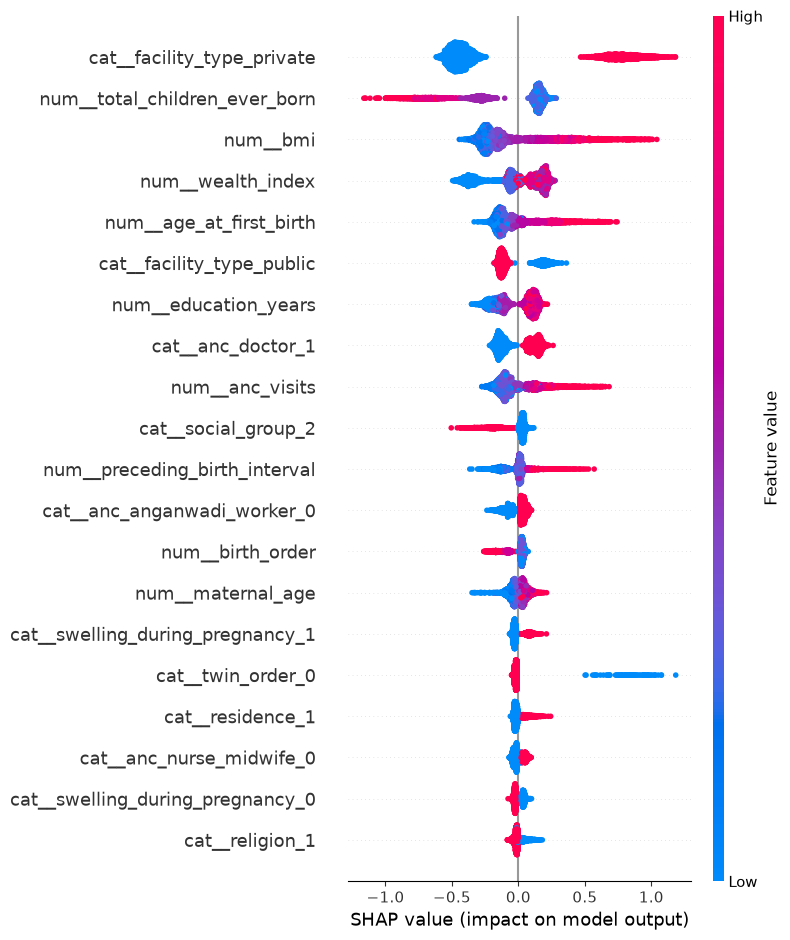

Saved: ..\..\outputs\figures\b2_shap_beeswarm.png


In [11]:
shap.summary_plot(shap_matrix, X_shap_transformed, feature_names=transformed_feature_names, show=False, max_display=20)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b2_shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES_DIR / "b2_shap_beeswarm.png")

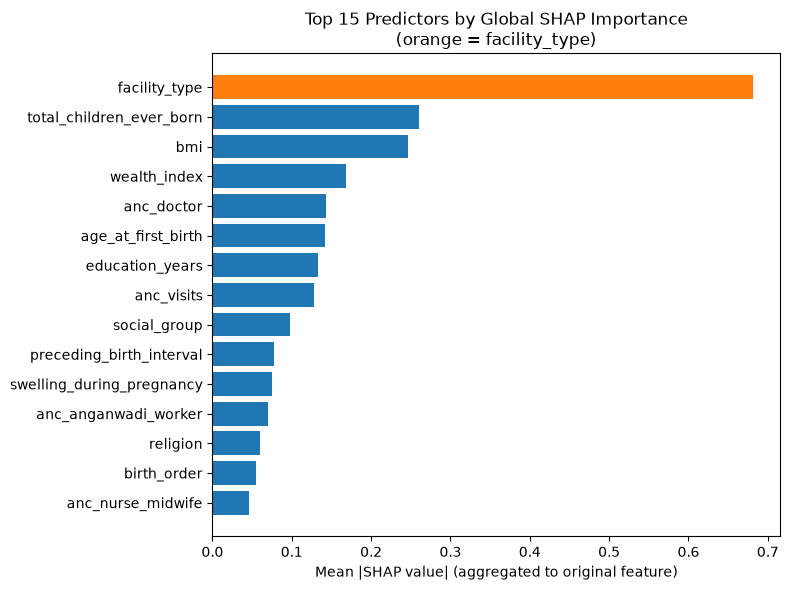

Saved: ..\..\outputs\figures\b2_shap_original_feature_bar.png


In [12]:
top_n = 15
top_features = original_feature_importance.head(top_n).iloc[::-1]  # reversed for horizontal bar order
colors = ["tab:orange" if is_fac else "tab:blue" for is_fac in top_features["is_facility_type"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features["original_feature"], top_features["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value| (aggregated to original feature)")
ax.set_title(f"Top {top_n} Predictors by Global SHAP Importance\n(orange = facility_type)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b2_shap_original_feature_bar.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b2_shap_original_feature_bar.png")

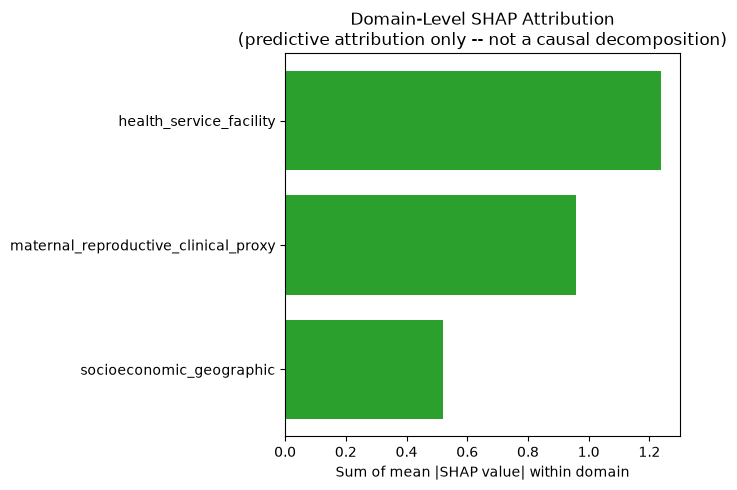

Saved: ..\..\outputs\figures\b2_shap_domain_bar.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
domain_plot_order = domain_importance.sort_values("mean_abs_shap")
ax.barh(domain_plot_order["domain"], domain_plot_order["mean_abs_shap"], color="tab:green")
ax.set_xlabel("Sum of mean |SHAP value| within domain")
ax.set_title("Domain-Level SHAP Attribution\n(predictive attribution only -- not a causal decomposition)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b2_shap_domain_bar.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b2_shap_domain_bar.png")

## 12. Save metadata

In [14]:
metadata = {
    "random_state": RANDOM_STATE,
    "model_source": model_source,
    "shap_method": "shap.TreeExplainer on the fitted XGBClassifier step (positive class selected if 3D output)",
    "sample": {
        "requested_size": SHAP_SAMPLE_SIZE,
        "actual_size": int(len(X_shap_sample)),
        "sampling_method": "class-stratified random sample without replacement, drawn only from locked test indices",
        "sample_class_balance": float(y_shap_sample.mean()),
        "test_set_class_balance": float(y_test.mean()),
    },
    "consistency_check_against_b2": {
        "fresh_roc_auc": float(fresh_roc_auc),
        "fresh_pr_auc": float(fresh_pr_auc),
        "fresh_brier": float(fresh_brier),
        "tolerance": TOLERANCE,
    },
    "domain_mapping_source": str(VARIABLE_DICT_PATH),
    "domain_override": "facility_type reassigned from its dictionary 'exposure' tag to the health_service_facility domain for this predictive-attribution analysis",
    "n_predictors": len(feature_cols),
    "n_transformed_features": int(len(transformed_feature_names)),
}

with open(METADATA_DIR / "b2_shap_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b2_shap_metadata.json")

Saved: ..\..\outputs\metadata\b2_shap_metadata.json
